# Tutorial 3: Image Generation (VAEs & GANs)

This tutorial explores two foundational frameworks for image generation: Variational Autoencoders (VAEs) and Generative Adversarial Networks (GANs).
We will examine how VAEs structure probabilistic latent spaces and how GANs leverage adversarial training to generate images implicitly.

## Part 1: Variational Autoencoders (VAEs)

We begin by extending Autoencoders into the probabilistic domain to enable generative capabilities. After mastering the reparameterization trick, we will see how VAEs act as essential perceptual compression stages for Latent Diffusion, facilitating both discrete (VQ) and continuous (KL) latent representations.

### **1.1 From AE to VAE**

#### **1.1.1 Deterministic Bottleneck Representation**

Let us start by reviewing the standard **Autoencoder**. Originally, these models were designed for tasks like **dimensionality reduction** and **denoising**. Their primary goal is to learn a compact summary of the input data rather than to generate new data from scratch.

The core mechanism relies on **compression** and **decompression**. The network forces the image through a very narrow channel called the **bottleneck**. This constraint compels the model to discard unnecessary noise and retain only the most essential **features** required to reconstruct the image.

In this architecture, the mapping process is **deterministic**. This means that if you input the same image multiple times, the Encoder will always produce the exact same **latent vector**. It maps the input to a single fixed point, which makes it excellent for representation but limited for generation.

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


mnist_autoencoder_zdim2.pth:   0%|          | 0.00/4.28M [00:00<?, ?B/s]

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 480kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.49MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.0MB/s]


Latent Coordinates (Run 1): [0.9310, -7.6456]
Latent Coordinates (Run 2): [0.9310, -7.6456]
Difference: 0.0
Is the mapping deterministic? YES


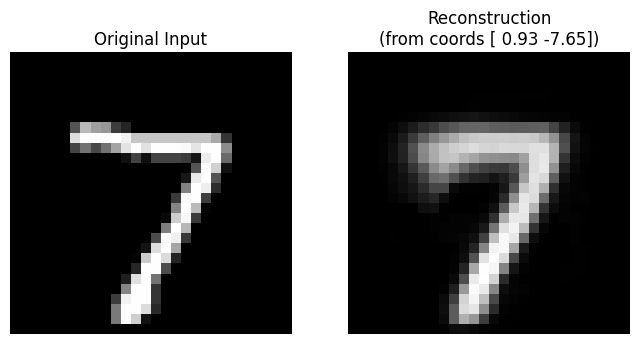

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from huggingface_hub import hf_hub_download
import matplotlib.pyplot as plt
import numpy as np

# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Define the Standard Autoencoder Architecture
# This matches the "Deep" structure: 784 -> 512 -> 256 -> 2
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        # Encoder: Compresses input to a 2D bottleneck
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 2) # Latent Dim = 2
        )
        # Decoder: Reconstructs from the 2D bottleneck
        self.decoder = nn.Sequential(
            nn.Linear(2, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        x_flat = x.view(x.size(0), -1)
        z = self.encoder(x_flat)
        recon = self.decoder(z)
        return recon.view(x.size(0), 1, 28, 28), z

# 2. Load Pre-trained Model from Hugging Face
model = Autoencoder().to(DEVICE)
model_path = hf_hub_download(repo_id="oliveryanzuolu/70113_GenAI_helper_models",
                             filename="mnist_autoencoder_zdim2.pth")
model.load_state_dict(torch.load(model_path, map_location=DEVICE))
model.eval()

# 3. Get a Single Test Image
transform = transforms.ToTensor()
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
img, _ = test_data[0] # Pick the first image (a '7')
img = img.unsqueeze(0).to(DEVICE) # Add batch dimension

# 4. Demonstrate Determinism
# We pass the SAME image through the encoder twice
with torch.no_grad():
    recon1, z1 = model(img)
    recon2, z2 = model(img)

# Check if the latent vectors are identical
difference = torch.sum(torch.abs(z1 - z2)).item()
is_deterministic = difference == 0.0

print(f"Latent Coordinates (Run 1): [{z1[0,0]:.4f}, {z1[0,1]:.4f}]")
print(f"Latent Coordinates (Run 2): [{z2[0,0]:.4f}, {z2[0,1]:.4f}]")
print(f"Difference: {difference}")
print(f"Is the mapping deterministic? {'YES' if is_deterministic else 'NO'}")

# 5. Visualize Reconstruction
plt.figure(figsize=(8, 4))

# Original
plt.subplot(1, 2, 1)
plt.imshow(img.cpu().squeeze(), cmap='gray')
plt.title("Original Input")
plt.axis('off')

# Reconstructed
plt.subplot(1, 2, 2)
plt.imshow(recon1.cpu().squeeze(), cmap='gray')
plt.title(f"Reconstruction\n(from coords {z1[0].cpu().numpy().round(2)})")
plt.axis('off')

plt.show()


#### **1.1.2 Discontinuity in Latent Space**

So, why exactly is it limited for generation? The main limitation lies in the structure of the **latent space**. A standard Autoencoder focuses only on minimizing reconstruction error. It does not care about how the latent vectors are organized or distributed.

Imagine we plot all the latent vectors of our training data on a 2D plane. You would see that the data points form **isolated clusters**. For example, all the vectors for the digit "1" might be in one corner, and vectors for "7" in another. Crucially, there are large **empty gaps** between these clusters. The model never learned what these empty areas represent during training.

This causes a major problem when we try to generate new content. If you pick a random point from these empty regions and feed it into the decoder, the result will not be a valid image. Instead, the decoder will output **meaningless noise**. This happens because the latent space of a standard Autoencoder is **discontinuous**. To build a good generative model, we need a continuous space where every point maps to a meaningful output.


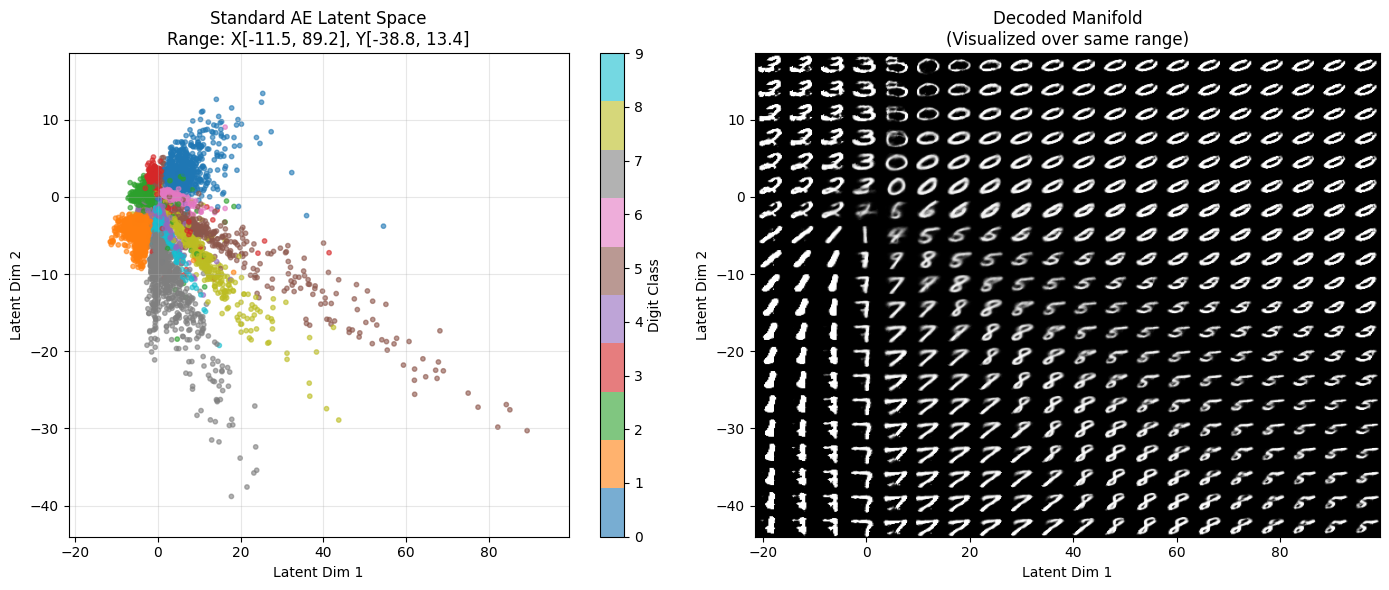

In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from huggingface_hub import hf_hub_download
import matplotlib.pyplot as plt
import numpy as np

# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Define the Standard Autoencoder Architecture
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(2, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        x_flat = x.view(x.size(0), -1)
        z = self.encoder(x_flat)
        recon = self.decoder(z)
        return recon.view(x.size(0), 1, 28, 28), z

# 2. Load Pre-trained Model
model = Autoencoder().to(DEVICE)
model_path = hf_hub_download(repo_id="oliveryanzuolu/70113_GenAI_helper_models",
                             filename="mnist_autoencoder_zdim2.pth")
model.load_state_dict(torch.load(model_path, map_location=DEVICE))
model.eval()

# 3. Get Test Data
test_dataset = datasets.MNIST(root='./data', train=False, transform=transforms.ToTensor(), download=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=10000, shuffle=False)
images, labels = next(iter(test_loader))
images = images.to(DEVICE)

# 4. Generate Visualization
plt.figure(figsize=(14, 6))

# --- Step 1: Calculate Common Bounds ---
with torch.no_grad():
    _, z_points = model(images)
    z_points = z_points.cpu().numpy()

# Get the absolute min/max of the data
x_min, x_max = z_points[:, 0].min(), z_points[:, 0].max()
y_min, y_max = z_points[:, 1].min(), z_points[:, 1].max()

# Add a 10% margin so points aren't on the edge
margin_x = (x_max - x_min) * 0.1
margin_y = (y_max - y_min) * 0.1
x_lims = [x_min - margin_x, x_max + margin_x]
y_lims = [y_min - margin_y, y_max + margin_y]

# --- Plot A: Scatter Plot ---
ax1 = plt.subplot(1, 2, 1)
scatter = ax1.scatter(z_points[:, 0], z_points[:, 1], c=labels, cmap='tab10', alpha=0.6, s=10)
ax1.set_xlim(x_lims)
ax1.set_ylim(y_lims)
ax1.set_title(f"Standard AE Latent Space\nRange: X[{x_min:.1f}, {x_max:.1f}], Y[{y_min:.1f}, {y_max:.1f}]")
ax1.set_xlabel("Latent Dim 1")
ax1.set_ylabel("Latent Dim 2")
plt.colorbar(scatter, ax=ax1, label="Digit Class")
ax1.grid(True, alpha=0.3)

# --- Plot B: Manifold Grid ---
ax2 = plt.subplot(1, 2, 2)

n = 20  # Grid resolution
digit_size = 28
canvas = np.zeros((digit_size * n, digit_size * n))

# Create grid using the SAME limits as Plot A
grid_x = np.linspace(x_lims[0], x_lims[1], n)
grid_y = np.linspace(y_lims[1], y_lims[0], n) # Inverted Y for image drawing order

with torch.no_grad():
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]]).float().to(DEVICE)
            x_decoded = model.decoder(z_sample)
            digit = x_decoded.view(digit_size, digit_size).cpu().numpy()
            canvas[i * digit_size: (i + 1) * digit_size,
                   j * digit_size: (j + 1) * digit_size] = digit

ax2.imshow(canvas, cmap='Greys_r',
           extent=[x_lims[0], x_lims[1], y_lims[0], y_lims[1]],
           aspect='auto')

ax2.set_title("Decoded Manifold\n(Visualized over same range)")
ax2.set_xlabel("Latent Dim 1")
ax2.set_ylabel("Latent Dim 2")

plt.tight_layout()
plt.show()


#### **1.1.3 Probabilistic Latent Mapping**

The genius of the VAE lies in a simple but powerful change. It no longer maps an input image to a single fixed point in the latent space. Instead, it maps the image to a **probability distribution**. In most cases, we choose a normal distribution to represent this.

Let us look at the difference in coordinates. A standard Autoencoder might tell you that an image belongs exactly at the coordinates $(3, 4)$. A VAE works differently. The Encoder now tells you that the image is located **roughly around** $(3, 4)$ with a **variance** of 1. It predicts a mean and a standard deviation rather than just a specific position.

This means that every data point is transformed. It is no longer a tiny, isolated dot. It becomes a **cloud** that covers a certain range in the latent space. As we train the model, these clouds expand and begin to overlap with each other. They effectively fill up the empty gaps that existed in the deterministic model.

This approach solves the problem of discontinuity. Since these clouds fill the space, we can sample a point from **anywhere** in this region. Even if we pick a spot between two original data points, the Decoder can still produce a meaningful output. This capability is the **essential leap** that turns a standard Autoencoder into a generative model.

mnist_vae_zdim2.pth:   0%|          | 0.00/4.28M [00:00<?, ?B/s]

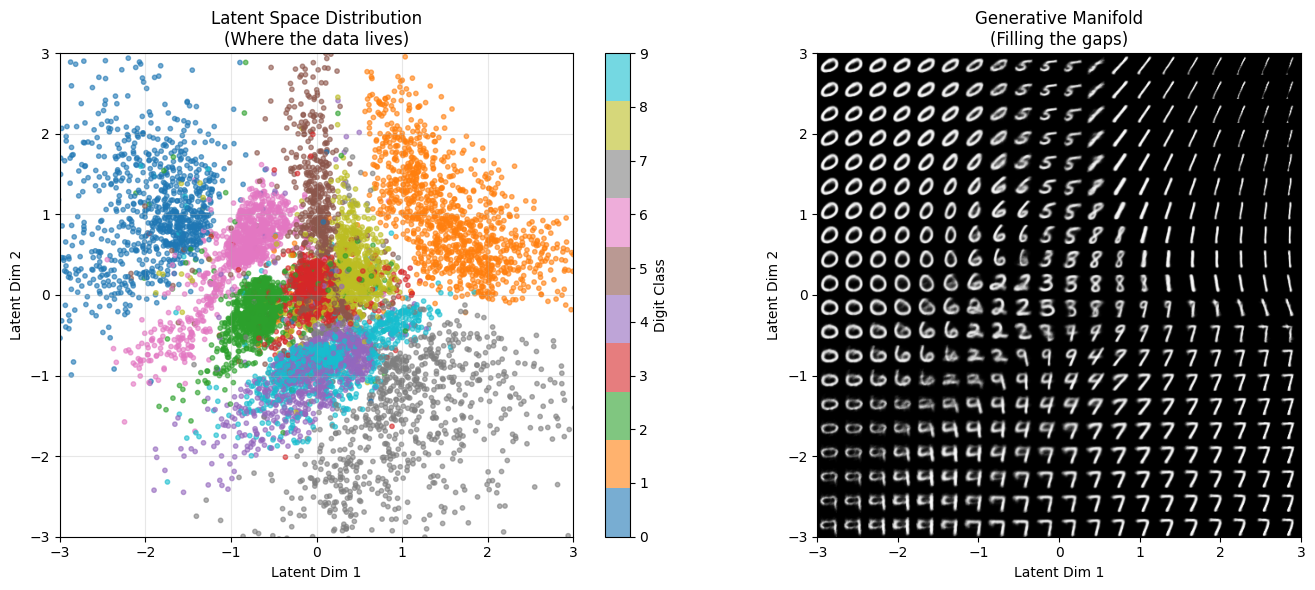

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from huggingface_hub import hf_hub_download
import matplotlib.pyplot as plt
import numpy as np

# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Define the Probabilistic Model Architecture
# This must match the saved model structure exactly
class VAE(nn.Module):
    def __init__(self, x_dim, h_dim1, h_dim2, z_dim):
        super(VAE, self).__init__()
        # Encoder
        self.fc1 = nn.Linear(x_dim, h_dim1)
        self.fc2 = nn.Linear(h_dim1, h_dim2)
        self.fc31 = nn.Linear(h_dim2, z_dim) # Mean (mu)
        self.fc32 = nn.Linear(h_dim2, z_dim) # Log Variance
        # Decoder
        self.fc4 = nn.Linear(z_dim, h_dim2)
        self.fc5 = nn.Linear(h_dim2, h_dim1)
        self.fc6 = nn.Linear(h_dim1, x_dim)

    def encoder(self, x):
        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))
        return self.fc31(h), self.fc32(h)

    def decoder(self, z):
        h = F.relu(self.fc4(z))
        h = F.relu(self.fc5(h))
        return torch.sigmoid(self.fc6(h))

# 2. Load Pre-trained Weights
model = VAE(x_dim=784, h_dim1=512, h_dim2=256, z_dim=2).to(DEVICE)
model_path = hf_hub_download(repo_id="oliveryanzuolu/70113_GenAI_helper_models",
                             filename="mnist_vae_zdim2.pth")
model.load_state_dict(torch.load(model_path, map_location=DEVICE))
model.eval()

# 3. Prepare Data for Scatter Plot
# We use the test set to see where real images fall in this new space
test_dataset = datasets.MNIST(root='./data', train=False, transform=transforms.ToTensor(), download=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=10000, shuffle=False)
images, labels = next(iter(test_loader))
images = images.to(DEVICE)

# 4. Generate Visualization
# We define a fixed range for both plots to ensure they align visually
RANGE = 3.0  # The latent space usually falls between -3 and 3 (Normal Distribution)

plt.figure(figsize=(14, 6))

# --- Plot A: The Latent "Clouds" (Scatter) ---
ax1 = plt.subplot(1, 2, 1)
with torch.no_grad():
    # We map images to their Mean (mu) location
    mu, _ = model.encoder(images.view(-1, 784))
    z_points = mu.cpu().numpy()

scatter = ax1.scatter(z_points[:, 0], z_points[:, 1], c=labels, cmap='tab10', alpha=0.6, s=10)
ax1.set_xlim(-RANGE, RANGE)
ax1.set_ylim(-RANGE, RANGE)
ax1.set_title("Latent Space Distribution\n(Where the data lives)")
ax1.set_xlabel("Latent Dim 1")
ax1.set_ylabel("Latent Dim 2")
plt.colorbar(scatter, ax=ax1, label="Digit Class")
ax1.grid(True, alpha=0.3)

# --- Plot B: The Continuous Manifold (Grid) ---
ax2 = plt.subplot(1, 2, 2)

n = 20  # Resolution of the grid (20x20 images)
digit_size = 28
canvas = np.zeros((digit_size * n, digit_size * n))

# We construct the grid to match the Cartesian coordinates of Plot A
# Y-axis: From +RANGE (Top) to -RANGE (Bottom)
# X-axis: From -RANGE (Left) to +RANGE (Right)
grid_y = np.linspace(RANGE, -RANGE, n)
grid_x = np.linspace(-RANGE, RANGE, n)

with torch.no_grad():
    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]]).float().to(DEVICE)
            x_decoded = model.decoder(z_sample)
            digit = x_decoded.view(digit_size, digit_size).cpu().numpy()

            # Fill the canvas
            canvas[i * digit_size: (i + 1) * digit_size,
                   j * digit_size: (j + 1) * digit_size] = digit

# Display the canvas
# extent defines the [left, right, bottom, top] in data coordinates
ax2.imshow(canvas, cmap='Greys_r', extent=[-RANGE, RANGE, -RANGE, RANGE])
ax2.set_title("Generative Manifold\n(Filling the gaps)")
ax2.set_xlabel("Latent Dim 1")
ax2.set_ylabel("Latent Dim 2")

plt.tight_layout()
plt.show()


### **1.2 VAE for Probabilistic Modeling**

#### **1.2.1 The Reparameterization Trick**

To generate the latent vector $z$, we need to sample from the distribution defined by our encoder. However, this creates a major technical challenge. **Direct sampling** is a stochastic, or random, operation. In a neural network, we cannot calculate gradients through a random node. This means the **backpropagation** process breaks, and the encoder cannot be updated.

To solve this, VAEs use a clever mathematical method called the **Reparameterization Trick**. The core idea is to separate the deterministic parts of the network from the random parts. Instead of sampling $z$ directly inside the network, we introduce an external source of randomness. We sample a noise variable, usually denoted as **$\epsilon$** (epsilon), from a standard normal distribution.

We then construct the latent vector $z$ using a specific formula: **$z = \mu + \sigma \cdot \epsilon$**. In this equation, $\mu$ and $\sigma$ are the outputs from the encoder, and $\epsilon$ is the independent noise. By doing this, we shift the randomness entirely to $\epsilon$. Since $\epsilon$ is just an input, we do not need to calculate gradients for it.

Now, the variables $\mu$ and $\sigma$ are simply part of a standard addition and multiplication operation. This allows the **gradients to flow** smoothly back through the network to the encoder. Thanks to this trick, the entire VAE model becomes differentiable and can be trained end-to-end.

In [ ]:
import torch
from torch.distributions import Normal

# Simulate Encoder outputs: mu and sigma (std dev)
# requires_grad=True simulates that these are learnable outputs from a Neural Network
mu = torch.randn(2, requires_grad=True)
sigma = torch.rand(2, requires_grad=True) # sigma must be positive

print(f"Encoder outputs:\n mu:    {mu.data}\n sigma: {sigma.data}\n")

# ==========================================
# Approach 1: Direct Sampling (Why it fails)
# ==========================================
print("--- 1. Direct Sampling (The Problem) ---")

# Define distribution based on current encoder outputs
dist = Normal(mu, sigma)

# .sample() generates a value directly from the distribution.
# This operation is non-differentiable; it breaks the link to mu and sigma.
z_direct = dist.sample()

print(f"z_direct requires_grad: {z_direct.requires_grad}") # Output: False

try:
    # Attempting to calculate gradients based on z_direct
    loss = z_direct.sum()
    loss.backward()
except RuntimeError as e:
    print(f"\n[Error] Backpropagation failed!\nMessage: {e}")
    print("Explanation: The gradient chain is broken because sampling is a stochastic node.")

# ==========================================
# Approach 2: Reparameterization Trick (The Solution)
# ==========================================
print("\n--- 2. Reparameterization Trick (The Solution) ---")

# Step A: Sample independent noise (epsilon)
# This is just a constant input tensor, no gradients needed for it
epsilon = torch.randn_like(sigma)

# Step B: Transform (Shift and Scale)
# z = mu + sigma * epsilon
# This is just addition and multiplication, which are fully differentiable
z_reparam = mu + sigma * epsilon

print(f"z_reparam requires_grad: {z_reparam.requires_grad}") # Output: True

# Verify Backpropagation
loss = z_reparam.sum()
loss.backward()

print("\n[Success] Gradients calculated successfully:")
print(f"Gradient on mu:    {mu.grad}")    # Should be 1.0 (derivative of sum)
print(f"Gradient on sigma: {sigma.grad}") # Should be epsilon (derivative of sum)


#### **1.2.2 Balancing Reconstruction and Divergence**

To train a VAE, we minimize a loss function that consists of two competing parts. The first part is the **Reconstruction Loss**. Its goal is simple. It measures the difference between the original input image and the decoded output image. This term forces the model to reproduce the input details as accurately as possible.

The second part is the **KL Divergence**. This term acts as a constraint on the latent space. It forces the distribution of the learned latent variables to look like a **standard normal distribution**. This ensures that the latent space remains smooth and continuous.

Training a VAE is essentially a balancing act between these two objectives. If we ignore the **KL Divergence**, the model degenerates into a standard Autoencoder. The latent space becomes discontinuous, and we lose the ability to generate new samples. However, if the **KL Divergence** is too strong, the latent variables become pure noise. In this case, the decoder fails to learn meaningful features, and the generated images look blurry or generic. We must optimize both terms together to achieve high-quality generation.

In [ ]:
import torch
import torch.nn.functional as F

def vae_loss_function(recon_x, x, mu, logvar, kl_weight=1.0):
    """
    Computes the VAE loss: Reconstruction + KL Divergence.
    """
    # 1. Reconstruction Loss: Measures fidelity (Pixel-wise MSE)
    # reduction='sum' is used to maintain magnitude balance with KL
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')

    # 2. KL Divergence: Measures latent space smoothness
    # Analytic KL between N(mu, sigma^2) and N(0, 1)
    # Formula: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # Total Loss: Balancing the two objectives
    total_loss = recon_loss + (kl_weight * kl_loss)

    return total_loss, recon_loss, kl_loss

# --- Example Usage ---
# Mock data: Batch of 64 images (1 channel, 28x28) and 20-dim latent space
B, C, H, W = 64, 1, 28, 28
latent_dim = 20

x = torch.randn(B, C, H, W)        # Original input
recon_x = torch.randn(B, C, H, W)  # Decoder output
mu = torch.randn(B, latent_dim)    # Encoder output (mean)
logvar = torch.randn(B, latent_dim)# Encoder output (log variance)

# Calculate loss
loss, recon, kl = vae_loss_function(recon_x, x, mu, logvar)

print(f"Reconstruction Loss: {recon.item():.2f} (Forces fidelity)")
print(f"KL Divergence:       {kl.item():.2f} (Forces normal distribution)")
print(f"Total VAE Loss:      {loss.item():.2f}")


#### **1.2.3 Generative Sampling Process**

Once the training process is finished, we arrive at the true magic of the VAE. At this stage, we no longer need the **Encoder** network. We also do not need to provide any input images to the model.

Remember that during training, our loss function forced the latent space to look like a **standard normal distribution**. This design choice is crucial for the generation phase. Because the space is regular and continuous, we know exactly where to find valid latent codes.

To create a new image, we simply generate a random vector from a normal distribution with a mean of zero and a standard deviation of one. We then feed this random vector directly into the **Decoder**.

The Decoder takes this random noise and expands it back into a full image. Since the Decoder has learned the underlying structure of the data, it can "imagine" a new digit that it has never seen before. It demonstrates that our model is not just memorizing data, but is truly capable of **generative sampling**.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Define Model Architecture (Must match the saved weights)
class VAE(nn.Module):
    def __init__(self, x_dim, h_dim1, h_dim2, z_dim):
        super(VAE, self).__init__()
        # Encoder layers (Required to load weights, even if unused here)
        self.fc1 = nn.Linear(x_dim, h_dim1)
        self.fc2 = nn.Linear(h_dim1, h_dim2)
        self.fc31 = nn.Linear(h_dim2, z_dim)
        self.fc32 = nn.Linear(h_dim2, z_dim)
        # Decoder layers
        self.fc4 = nn.Linear(z_dim, h_dim2)
        self.fc5 = nn.Linear(h_dim2, h_dim1)
        self.fc6 = nn.Linear(h_dim1, x_dim)

    def decoder(self, z):
        h = F.relu(self.fc4(z))
        h = F.relu(self.fc5(h))
        return torch.sigmoid(self.fc6(h))

# 2. Load Pre-trained Weights
model = VAE(x_dim=784, h_dim1=512, h_dim2=256, z_dim=2).to(DEVICE)
model_path = hf_hub_download(repo_id="oliveryanzuolu/70113_GenAI_helper_models",
                             filename="mnist_vae_zdim2.pth")
model.load_state_dict(torch.load(model_path, map_location=DEVICE))
model.eval()

# 3. Generative Sampling Process
# We generate 16 new images from pure noise
num_samples = 16

# Step A: Sample from Standard Normal Distribution N(0, 1)
# No input images needed, just random latent codes
z_random = torch.randn(num_samples, 2).to(DEVICE)

# Step B: Feed noise directly to Decoder
with torch.no_grad():
    generated_images = model.decoder(z_random)

# 4. Visualization (2 Rows x 8 Columns)
plt.figure(figsize=(10, 3)) # Wide and compact

for i in range(num_samples):
    plt.subplot(2, 8, i + 1)
    # Reshape flat vector (784) back to image (28x28)
    img = generated_images[i].view(28, 28).cpu().numpy()
    plt.imshow(img, cmap='gray')
    plt.axis('off')

plt.suptitle("Generative Sampling from N(0,1)", fontsize=12, y=0.98)
plt.tight_layout()
plt.show()


### **1.3 VAE for Perceptual Compression**

#### **1.3.1 Vector Quantized Latent Representation**

So far, the VAE models we have discussed operate in a **continuous latent space**. We assumed that the latent variables follow a smooth distribution, such as a Gaussian distribution. However, in 2017, researchers at DeepMind proposed a different approach called **VQ-VAE** (https://arxiv.org/abs/1711.00937). Their key insight was that the essential features of an image might actually be **discrete**, similar to how language is constructed from distinct words rather than continuous sounds.

To achieve this, VQ-VAE introduces a central component known as a **Codebook**. You can think of the Codebook as a fixed list of learnable vectors. In this model, the Encoder still produces a feature vector, but we do not pass this vector directly to the Decoder. Instead, we compare the Encoder's output with every vector in the Codebook. We find the **nearest neighbor**, which is the vector in the Codebook that is most similar to the output. We then replace the original vector with this specific Codebook vector. This process of replacement is called **Vector Quantization**.

This mechanism changes the nature of the latent space. It transforms continuous signals into a grid of **discrete indices**. This design was originally developed to solve a common training failure called **Posterior Collapse**, where the model ignores the latent variables. Additionally, this approach generates **sharper images**. While a standard VAE might produce a blurry approximation, the VQ-VAE forces the fuzzy signal to "snap" to a clear and distinct feature defined in the Codebook.

In [ ]:
import torch
import torch.nn as nn

# --- 1. Setup & Mock Data ---
B, C, H, W = 1, 4, 2, 2  # Batch, Channels, Height, Width
num_embeddings = 10000      # Codebook size (K)

# Encoder output (Continuous)
z_e = torch.randn(B, C, H, W)

# The Codebook (Learnable dictionary of K vectors with dim C)
embedding = nn.Embedding(num_embeddings, C)
embedding.weight.data.uniform_(-1.0, 1.0)

print(f"Original Continuous Vector (pixel 0,0):\n {z_e[0, :, 0, 0].detach().numpy()}")

# --- 2. Vector Quantization (The "Snap" Mechanism) ---
# Flatten input to (N, C) for distance calculation
z_e_flat = z_e.permute(0, 2, 3, 1).contiguous().view(-1, C)

# Calculate squared L2 distance: (a-b)^2 = a^2 + b^2 - 2ab
d2 = torch.sum(z_e_flat ** 2, dim=1, keepdim=True) + \
     torch.sum(embedding.weight ** 2, dim=1) - \
     2 * torch.matmul(z_e_flat, embedding.weight.t())

# Find the nearest neighbor (argmin) in the codebook
min_encoding_indices = torch.argmin(d2, dim=1)

# --- 3. Quantize ---
# Replace encoder output with the nearest codebook vector
z_q = embedding(min_encoding_indices).view(B, H, W, C).permute(0, 3, 1, 2)

print(f"\nMapped to Codebook Index: {min_encoding_indices[0].item()}")
print(f"Quantized Vector (from Codebook):\n {z_q[0, :, 0, 0].detach().numpy()}")

# Note: In training, we would use z_q = z_e + (z_q - z_e).detach()
# to allow gradients to flow back to the encoder (Straight-Through Estimator).


#### **1.3.2 Discrete Visual Tokenization**

The true power of **VQ-VAE** was fully realized during the era of **DALL-E 1**. OpenAI made a crucial discovery (https://arxiv.org/abs/2102.12092). They realized that if a VQ-VAE can map an image to a sequence of discrete numbers, then an image is essentially just another form of language. In this view, an image becomes a sequence of symbols, much like a sentence in a foreign language.

At this stage, the role of the VAE changes completely. It is no longer responsible for directly generating the final image. Instead, it acts as a **Tokenizer**. This reveals an interesting cycle in the history of these models. We started with Autoencoders for **compression**. Then we moved to standard VAEs for **generation**. Now, with VQ-VAE, we return to **compression** again, but with a new purpose. We compress the image specifically to make the generation process easier for a second model.

Technically, this process compresses a standard **256 by 256** RGB image into a much smaller **32 by 32** grid of discrete tokens. Because the image is now just a sequence of discrete integers, we can use the most powerful text models available, such as **Transformers** or GPT. The Transformer treats the image tokens exactly like words and learns to predict the next token in the sequence.

This establishes a powerful **two-stage generation** paradigm. In the first stage, we use the VAE to compress pixels into tokens. In the second stage, we use a Transformer to predict those tokens. This approach successfully bridged the gap between text and images, and also opened the door for modern large-scale image generation.

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# 1. Setup: Define dimensions simulating DALL-E 1 style tokenization
img_size = 256        # Input: 256x256 RGB
patch_size = 8        # Downsampling factor (256 / 8 = 32)
num_embeddings = 8192 # Size of the "Visual Vocabulary" (Codebook)
embedding_dim = 64    # Dimension of each code vector

# 2. Mock VQ-Tokenizer Components
# Encoder: Compresses 256x256x3 -> 32x32x64
encoder = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=4, stride=2, padding=1), # 128x128
    nn.ReLU(),
    nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1), # 64x64
    nn.ReLU(),
    nn.Conv2d(32, embedding_dim, kernel_size=4, stride=2, padding=1) # 32x32
)

# Codebook: The "Dictionary" of visual words
codebook = nn.Embedding(num_embeddings, embedding_dim)
codebook.weight.data.uniform_(-1.0 / num_embeddings, 1.0 / num_embeddings)

# 3. Create a dummy image (Gradient pattern)
x = torch.linspace(-1, 1, img_size)
y = torch.linspace(-1, 1, img_size)
xx, yy = torch.meshgrid(x, y, indexing='ij')
dummy_img = torch.stack([xx, yy, xx*yy], dim=0).unsqueeze(0) # [1, 3, 256, 256]

# 4. Tokenization Process (Forward Pass)
with torch.no_grad():
    # A. Encode pixels to continuous latent vectors
    z_e = encoder(dummy_img) # Shape: [1, 64, 32, 32]

    # B. Reshape for quantization: [Batch, Height, Width, Channel]
    z_e_permuted = z_e.permute(0, 2, 3, 1).contiguous()
    flattened = z_e_permuted.view(-1, embedding_dim) # [1024, 64]

    # C. Vector Quantization: Find nearest neighbor in codebook
    # Calculate distances: (z - e)^2 = z^2 + e^2 - 2ze
    d2 = torch.sum(flattened ** 2, dim=1, keepdim=True) + \
         torch.sum(codebook.weight ** 2, dim=1) - \
         2 * torch.matmul(flattened, codebook.weight.t())

    # Get the index of the closest codebook vector (The "Token")
    encoding_indices = torch.argmin(d2, dim=1).view(1, 32, 32)

# 5. Visualization
print(f"Original Image Shape: {dummy_img.shape} (Continuous Pixels)")
print(f"Token Map Shape:      {encoding_indices.shape} (Discrete Integers)")

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
# Original Image
ax[0].imshow(dummy_img[0].permute(1, 2, 0) * 0.5 + 0.5)
ax[0].set_title("Input Image (256x256)")
ax[0].axis('off')

# Discrete Tokens
# We visualize the indices directly to show the "grid of symbols" structure
im = ax[1].imshow(encoding_indices[0].cpu(), cmap='tab20')
ax[1].set_title("Discrete Visual Tokens (32x32)")
ax[1].axis('off')
plt.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


#### **1.3.3 Perceptual Compression in Latent Diffusion**

Finally, let us look at the **Latent Diffusion Model**, or **LDM**. You likely know this model by its popular name, **Stable Diffusion** (https://arxiv.org/abs/2112.10752). This model takes the idea of two-stage generation even further. In the previous section, we saw how VQVAE acts like a tokenizer. LDM formally introduces the concept of **Perceptual Compression**. The goal is to use an autoencoder to remove high-frequency details that are not essential for semantic meaning. This allows the diffusion model to focus on the important structure in a compressed, efficient space.

In the original LDM paper, the authors experimented with two types of regularization for this compression stage. The first is **KL-regularization**, which uses a continuous latent space similar to a standard VAE. The second is **VQ-regularization**, which uses a discrete latent space like VQVAE. They wanted to determine which approach provided the best foundation for training diffusion models.

The experiments revealed an interesting trade-off. The **KL-reg** models generally achieved better reconstruction metrics, such as **PSNR** and **SSIM**. On the other hand, models trained on the discrete **VQ-reg** space sometimes produced generated samples with higher visual quality. However, for large-scale text-to-image tasks, the continuous KL-regularized VAE proved to be more effective. As a result, it became the standard configuration for **Stable Diffusion** and established the current **best practice** in the industry.

Regardless of whether we choose KL or VQ regularization, there is one shared challenge. Standard VAE losses often result in slightly blurry images. To solve this and ensure the model reconstructs high-resolution details perfectly, LDM introduces an **adversarial loss**, or **GAN loss**, during the training of the VAE. This acts like a strict "examiner" or "discriminator" that specifically checks if the image textures are sharp and realistic. You might wonder how this examiner works. That is exactly what we will explore in the **Part 2**, where we discuss Generative Adversarial Networks (GANs).

In [ ]:
import torch
import requests
from PIL import Image
from io import BytesIO
from diffusers import AutoencoderKL
from torchvision import transforms
import matplotlib.pyplot as plt

# 1. Load the pre-trained VAE from Stable Diffusion v1.5
# We use the 'diffusers' library which hosts the standard SD components
model_id = "runwayml/stable-diffusion-v1-5"
vae = AutoencoderKL.from_pretrained(model_id, subfolder="vae")
vae.eval()

# 2. Prepare a sample image
url = "https://raw.githubusercontent.com/CompVis/stable-diffusion/main/assets/stable-samples/img2img/sketch-mountains-input.jpg"
response = requests.get(url)
init_image = Image.open(BytesIO(response.content)).convert("RGB").resize((512, 512))

# 3. Preprocess: [0, 1] -> [-1, 1] and format as batch tensor
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
img_tensor = transform(init_image).unsqueeze(0)  # Shape: [1, 3, 512, 512]

# 4. Encode: Compress image into Latent Space
# SD VAE compresses spatial dimensions by a factor of 8 (512/8 = 64)
with torch.no_grad():
    # Get the distribution and sample from it (using the reparameterization trick internally)
    posterior = vae.encode(img_tensor).latent_dist
    latents = posterior.sample()
    # Note: In actual diffusion inference, we also scale latents by a constant (0.18215)

# 5. Decode: Reconstruct image from Latent Space
with torch.no_grad():
    decoded_obj = vae.decode(latents)
    reconstructed = decoded_obj.sample # Shape: [1, 3, 512, 512]

# 6. Visualization and Dimension Check
# Post-process for display: [-1, 1] -> [0, 1]
reconstructed_img = (reconstructed / 2 + 0.5).clamp(0, 1).squeeze().permute(1, 2, 0).numpy()

print(f"Original Image Shape: {img_tensor.shape} (3 channels, high res)")
print(f"Latent Space Shape:   {latents.shape}    (4 channels, compressed 8x)")

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(init_image)
ax[0].set_title("Original Image (512x512)")
ax[0].axis("off")

ax[1].imshow(reconstructed_img)
ax[1].set_title("VAE Reconstruction (KL-Reg)")
ax[1].axis("off")
plt.show()


### **1.4 Exercise: Building a VAE for MNIST**

In this final exercise of Part 1, you will implement the core probabilistic components of a Variational Autoencoder. We will work with a 2-dimensional latent space ($z\_dim=2$) to allow for direct visualization of the learned manifold.

In the `encoder`, you will notice that the network does not predict the standard deviation $\sigma$ directly. Instead, it predicts the **logarithm of the variance**, denoted as `log_var` ($\log \sigma^2$).

**Why do we do this?**
1.  **Mathematical Constraints:** Standard deviation $\sigma$ must be strictly positive. A standard linear layer in a neural network outputs values in the range $(-\infty, \infty)$. If we tried to predict $\sigma$ directly, we would need activation functions like ReLU, which could lead to "dead" neurons (zero variance), or Softplus, which can be numerically unstable.
2.  **Stability:** By predicting $x = \log(\sigma^2)$, the network can output any real number. We can then safely recover the standard deviation using $\sigma = \exp(0.5 \times x)$. This ensures $\sigma$ is always positive and makes the optimization landscape smoother.

You need to complete the code in the `TODO` blocks:
1.  **Model Architecture:** Implement the `sampling` (reparameterization trick) and `forward` pass.
2.  **Loss Function:** Implement the Evidence Lower Bound (ELBO), which consists of:
    *   **Reconstruction Loss:** Binary Cross Entropy (BCE) between the input and the output.
    *   **KL Divergence:** The closed-form solution for Gaussian distributions:
        $$ D_{KL} = -0.5 \cdot \sum (1 + \log(\sigma^2) - \mu^2 - \sigma^2) $$



In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 100
EPOCHS = 30
LR = 1e-3

# Data Loading
print("Loading MNIST Data...")
train_dataset = datasets.MNIST(root='./data', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transforms.ToTensor(), download=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Loading MNIST Data...


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 475kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.43MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.3MB/s]


In [ ]:
class VAE(nn.Module):
    def __init__(self, x_dim, h_dim1, h_dim2, z_dim):
        super(VAE, self).__init__()

        # Encoder layers
        self.fc1 = nn.Linear(x_dim, h_dim1)
        self.fc2 = nn.Linear(h_dim1, h_dim2)
        self.fc31 = nn.Linear(h_dim2, z_dim) # Output: mu
        self.fc32 = nn.Linear(h_dim2, z_dim) # Output: log_var

        # Decoder layers
        self.fc4 = nn.Linear(z_dim, h_dim2)
        self.fc5 = nn.Linear(h_dim2, h_dim1)
        self.fc6 = nn.Linear(h_dim1, x_dim)

    def encoder(self, x):
        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))
        return self.fc31(h), self.fc32(h)

    def decoder(self, z):
        h = F.relu(self.fc4(z))
        h = F.relu(self.fc5(h))
        return torch.sigmoid(self.fc6(h))

    def sampling(self, mu, log_var):
        """
        Applies the Reparameterization Trick: z = mu + std * epsilon
        """
        # TODO: Implement reparameterization
        # 1. Calculate std = exp(0.5 * log_var)
        # 2. Generate eps from standard normal distribution (torch.randn_like)
        # 3. Return z = mu + eps * std
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def forward(self, x):
        # TODO: Tie it all together
        # 1. Flatten x (view to -1, 784)
        # 2. Encode to get mu and log_var
        # 3. Sample z
        # 4. Decode z
        # 5. Return reconstruction, mu, and log_var
        x = x.view(-1, 784)
        mu, log_var = self.encoder(x)
        z = self.sampling(mu, log_var)
        recon_x = self.decoder(z)
        return recon_x, mu, log_var

# Initialize Model
vae = VAE(x_dim=784, h_dim1=512, h_dim2=256, z_dim=2).to(DEVICE)
print(vae)

VAE(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc31): Linear(in_features=256, out_features=2, bias=True)
  (fc32): Linear(in_features=256, out_features=2, bias=True)
  (fc4): Linear(in_features=2, out_features=256, bias=True)
  (fc5): Linear(in_features=256, out_features=512, bias=True)
  (fc6): Linear(in_features=512, out_features=784, bias=True)
)


In [ ]:
optimizer = optim.Adam(vae.parameters(), lr=LR)

def loss_function(recon_x, x, mu, log_var):
    """
    Computes VAE Loss = Reconstruction Loss + KL Divergence
    """
    # TODO: Implement Reconstruction Loss
    # Use F.binary_cross_entropy with reduction='sum'
    # Hint: Flatten x to match recon_x shape
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction="sum")

    # TODO: Implement KL Divergence
    # Formula: -0.5 * sum(1 + log_var - mu^2 - exp(log_var))
    KLD = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    return BCE + KLD

In [ ]:
print(f"Training VAE on {DEVICE}...")
train_losses = []

for epoch in range(EPOCHS):
    vae.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(DEVICE)
        optimizer.zero_grad()

        # Forward pass
        try:
            recon_batch, mu, log_var = vae(data)
            loss = loss_function(recon_batch, data, mu, log_var)

            loss.backward()
            train_loss += loss.item()
            optimizer.step()
        except NotImplementedError:
            print("Error: VAE methods not implemented yet.")
            break

    avg_loss = train_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)

    if (epoch + 1) % 5 == 0:
        print(f'Epoch: {epoch+1} Average loss: {avg_loss:.4f}')

print("Training complete.")

Training VAE on cuda...
Epoch: 5 Average loss: 147.4112
Epoch: 10 Average loss: 142.6569
Epoch: 15 Average loss: 140.5324
Epoch: 20 Average loss: 139.3017
Epoch: 25 Average loss: 138.4459
Epoch: 30 Average loss: 137.4127
Training complete.


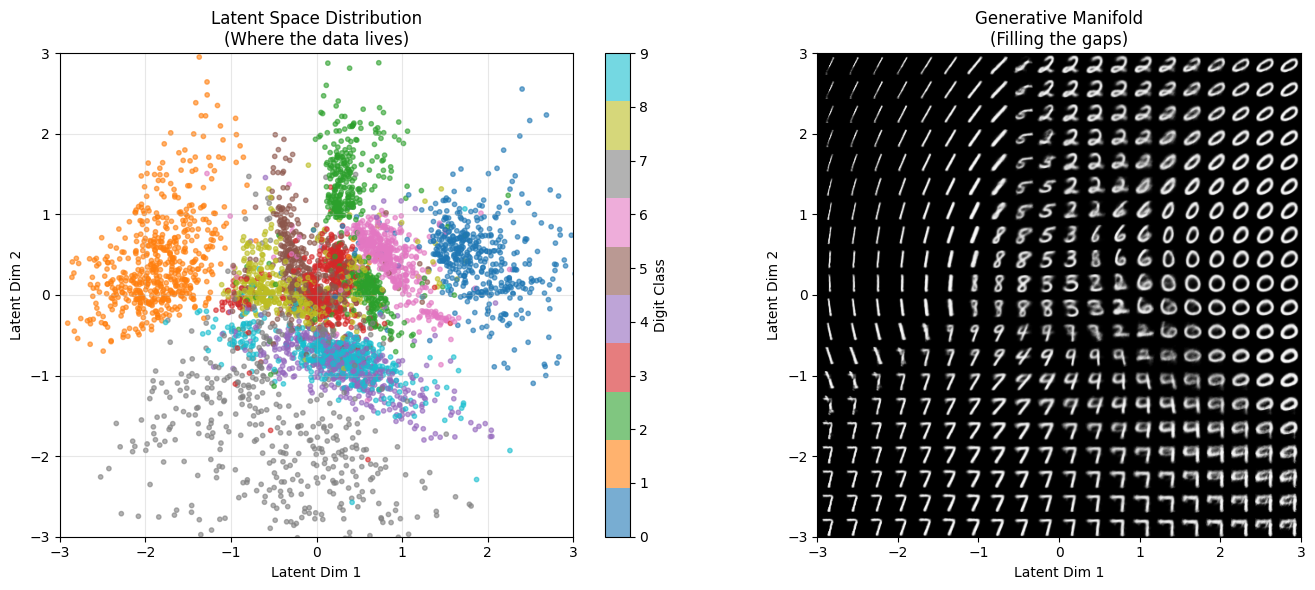

In [ ]:
def visualize_vae_performance(model, test_loader, device=DEVICE):
    """
    Visualizes the latent space and the generative manifold of a trained VAE.
    """
    model.eval()

    # 1. Prepare Data for Scatter Plot
    # We use a batch from the test set to see where real images fall
    images, labels = next(iter(test_loader))
    images = images.to(device)

    # 2. Generate Visualization
    RANGE = 3.0  # The latent space usually falls between -3 and 3

    plt.figure(figsize=(14, 6))

    # --- Plot A: The Latent "Clouds" (Scatter) ---
    ax1 = plt.subplot(1, 2, 1)
    with torch.no_grad():
        # We map images to their Mean (mu) location
        mu, _ = model.encoder(images.view(-1, 784))
        z_points = mu.cpu().numpy()

    scatter = ax1.scatter(z_points[:, 0], z_points[:, 1], c=labels, cmap='tab10', alpha=0.6, s=10)
    ax1.set_xlim(-RANGE, RANGE)
    ax1.set_ylim(-RANGE, RANGE)
    ax1.set_title("Latent Space Distribution\n(Where the data lives)")
    ax1.set_xlabel("Latent Dim 1")
    ax1.set_ylabel("Latent Dim 2")
    plt.colorbar(scatter, ax=ax1, label="Digit Class")
    ax1.grid(True, alpha=0.3)

    # --- Plot B: The Continuous Manifold (Grid) ---
    ax2 = plt.subplot(1, 2, 2)

    n = 20  # Resolution of the grid (20x20 images)
    digit_size = 28
    canvas = np.zeros((digit_size * n, digit_size * n))

    # We construct the grid to match the Cartesian coordinates of Plot A
    grid_y = np.linspace(RANGE, -RANGE, n)
    grid_x = np.linspace(-RANGE, RANGE, n)

    with torch.no_grad():
        for i, yi in enumerate(grid_y):
            for j, xi in enumerate(grid_x):
                z_sample = torch.tensor([[xi, yi]]).float().to(device)
                x_decoded = model.decoder(z_sample)
                digit = x_decoded.view(digit_size, digit_size).cpu().numpy()

                # Fill the canvas
                canvas[i * digit_size: (i + 1) * digit_size,
                       j * digit_size: (j + 1) * digit_size] = digit

    # Display the canvas
    ax2.imshow(canvas, cmap='Greys_r', extent=[-RANGE, RANGE, -RANGE, RANGE])
    ax2.set_title("Generative Manifold\n(Filling the gaps)")
    ax2.set_xlabel("Latent Dim 1")
    ax2.set_ylabel("Latent Dim 2")

    plt.tight_layout()
    plt.show()

# Run the visualization on your trained model
test_loader = DataLoader(dataset=test_dataset, batch_size=5000, shuffle=False)
visualize_vae_performance(vae, test_loader)

## Part 2: Generative Adversarial Networks (GANs)

We now turn to GANs, where generation is learned through an adversarial competition rather than explicit probability. We will cover the basic minimax dynamic, its application as an auxiliary training signal, and the essential loss function variants (e.g., WGAN, Hinge Loss) required for stable and high-fidelity results.

### **2.1 GAN for Implicit Modeling**

#### **2.1.1 Generator Manifold Mapping**

Let us start by defining the first core component of a GAN: the **Generator**. In this framework, the Generator is a neural network that creates data from scratch. Its input is a vector of random numbers, which we usually call **latent noise**. This noise is typically sampled from a very simple distribution, such as a standard **Gaussian distribution**.

Mathematically, the task of the Generator is to perform a mapping. It takes this simple **low-dimensional noise** and transforms it into a complex **high-dimensional sample**, such as an image with thousands of pixels. We often refer to the geometric shape of valid, realistic images as the **Data Manifold**. The Generator tries to learn a function that lands exactly on this manifold.

To visualize this process, you can imagine the noise space as a block of **soft clay**. The Generator acts like a sculptor. It stretches, bends, and molds this raw material until it matches the complex shape of the real data. Through this transformation, simple random numbers are turned into meaningful patterns.

It is important to note how this differs from the VAEs we discussed earlier. In a GAN, there is no **Encoder**. We do not map real images back to the noise space. If the training is successful, we can simply sample a random point from the noise space, pass it through the Generator, and the output will look just like a sample from the real dataset.

Loading pre-trained Generator weights...
Success! Generator is ready to map noise to data.

Mapping: Low-dim Input (8, 2) -> High-dim Output (8, 1, 16, 16)


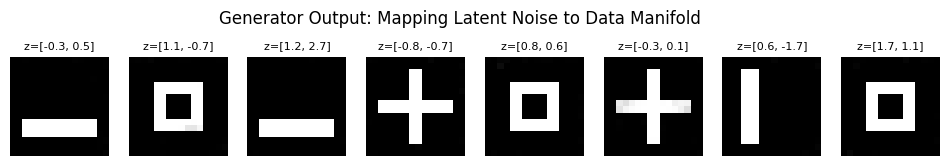

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

# ==========================================
# 1. Define the Generator (The "Sculptor")
# ==========================================
class MicroGenerator(nn.Module):
    def __init__(self, z_dim=2, hidden_dim=256):
        super(MicroGenerator, self).__init__()
        # 1. Linear Projection: Map noise (z) to a feature block
        self.fc = nn.Sequential(
            nn.Linear(z_dim, hidden_dim * 4 * 4),
            nn.BatchNorm1d(hidden_dim * 4 * 4),
            nn.ReLU(True)
        )
        self.hidden_dim = hidden_dim

        # 2. Transposed Convs: Upsample to image size (16x16)
        self.conv = nn.Sequential(
            nn.ConvTranspose2d(hidden_dim, 128, 4, 2, 1), # 4x4 -> 8x8
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 1, 4, 2, 1),          # 8x8 -> 16x16
            nn.Tanh() # Output activation [-1, 1]
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, self.hidden_dim, 4, 4) # Reshape to (Batch, Channel, H, W)
        return self.conv(x)

# ==========================================
# 2. Load Pre-trained Manifold
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
G = MicroGenerator().to(device)

# Download and load weights trained on the Toy Dataset (Squares, Crosses, Bars)
try:
    print("Loading pre-trained Generator weights...")
    model_path = hf_hub_download(repo_id="oliveryanzuolu/70113_GenAI_helper_models",
                                 filename="micro_gan_generator.pth")
    G.load_state_dict(torch.load(model_path, map_location=device))
    G.eval()
    print("Success! Generator is ready to map noise to data.")
except Exception as e:
    print(f"Warning: Could not load weights ({e}). Output will be random noise.")

# ==========================================
# 3. Execute Mapping: z -> Image
# ==========================================
# Sample random points from the latent space (Gaussian Noise)
z_dim = 2
num_samples = 8
z_noise = torch.randn(num_samples, z_dim).to(device)

# Pass through Generator
with torch.no_grad():
    generated_imgs = G(z_noise).cpu()

# ==========================================
# 4. Visualization
# ==========================================
print(f"\nMapping: Low-dim Input {tuple(z_noise.shape)} -> High-dim Output {tuple(generated_imgs.shape)}")

plt.figure(figsize=(12, 2))
for i in range(num_samples):
    plt.subplot(1, num_samples, i+1)
    # Visualize the generated image
    plt.imshow(generated_imgs[i].squeeze(), cmap='gray', vmin=-1, vmax=1)
    # Show the noise vector values that created this image
    plt.title(f"z=[{z_noise[i,0]:.1f}, {z_noise[i,1]:.1f}]", fontsize=8)
    plt.axis('off')
plt.suptitle("Generator Output: Mapping Latent Noise to Data Manifold")
plt.show()


#### **2.1.2 Discriminator Decision Boundary**

The Discriminator functions essentially as a **binary classifier**. While the Generator tries to create new data, the Discriminator acts as a judge. Its primary task is to examine an input image and classify it into one of two categories. It must decide if the image is a **real sample** from the training dataset or a **fake sample** produced by the Generator.

We can visualize this process in a high-dimensional feature space. The Discriminator attempts to learn a **decision boundary**. This is a dividing line or surface that separates the true data distribution from the generated distribution. A powerful Discriminator learns a boundary that fits very tightly around the real data. This forces the Generator to produce samples that fall exactly within that specific region to fool the judge.

Mathematically, the Discriminator outputs a single **scalar value**. In the vanilla GAN formulation, this value represents the **probability** that the input is real. A value close to 1 indicates high confidence that the image is real. A value close to 0 means the Discriminator believes the image is fake. This output provides the necessary feedback signal to update the weights of the Generator.

micro_gan_discriminator.pth:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

Overlaying generated shapes onto the latent space...


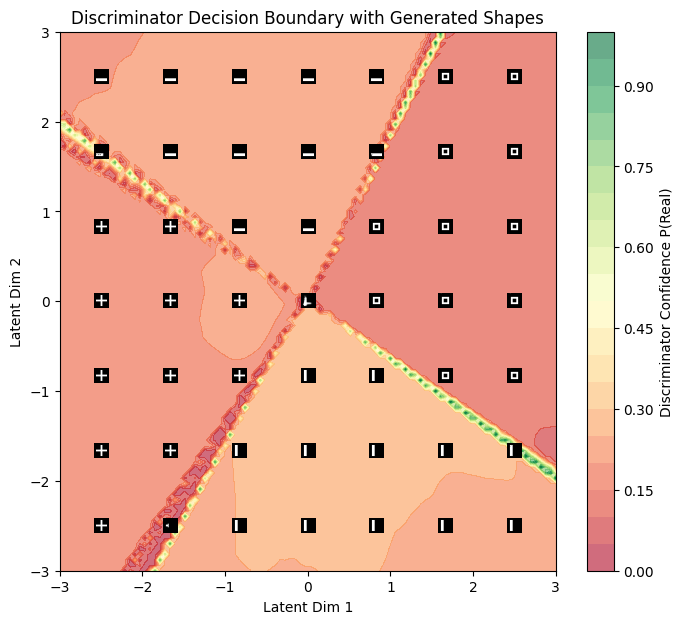

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from huggingface_hub import hf_hub_download

# ==========================================
# 1. Setup & Architecture (Must match training)
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Z_DIM = 2

class MicroGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(Z_DIM, 256 * 4 * 4), nn.BatchNorm1d(4096), nn.ReLU(True)
        )
        self.conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128, 1, 4, 2, 1), nn.Tanh()
        )
    def forward(self, z):
        return self.conv(self.fc(z).view(-1, 256, 4, 4))

class MicroDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 128, 4, 2, 1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, True),
            nn.Flatten(), nn.Linear(256 * 4 * 4, 1), nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

# ==========================================
# 2. Load Models
# ==========================================
print("Downloading models...")
repo = "oliveryanzuolu/70113_GenAI_helper_models"
g_path = hf_hub_download(repo_id=repo, filename="micro_gan_generator.pth")
d_path = hf_hub_download(repo_id=repo, filename="micro_gan_discriminator.pth")

G = MicroGenerator().to(DEVICE)
D = MicroDiscriminator().to(DEVICE)
G.load_state_dict(torch.load(g_path, map_location=DEVICE))
D.load_state_dict(torch.load(d_path, map_location=DEVICE))
G.eval(); D.eval()

# ==========================================
# 3. Visualize Decision Boundary & Shapes
# ==========================================
# A. Create a fine grid to visualize the Decision Boundary (Background)
resolution = 100
limit = 3
x = np.linspace(-limit, limit, resolution)
y = np.linspace(-limit, limit, resolution)
X, Y = np.meshgrid(x, y)
z_grid = torch.tensor(np.stack([X.ravel(), Y.ravel()], 1), dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    # 1. Generate images for the whole background grid
    gen_imgs_bg = G(z_grid)
    # 2. Discriminator scores these images (0=Fake, 1=Real)
    d_scores = D(gen_imgs_bg).cpu().numpy().reshape(resolution, resolution)

fig, ax = plt.subplots(figsize=(8, 7))
ax.set_title("Discriminator Decision Boundary with Generated Shapes")

# Plot Background: Red=Low Confidence (Fake), Green=High Confidence (Real)
contour = ax.contourf(X, Y, d_scores, levels=20, cmap='RdYlGn', vmin=0, vmax=1, alpha=0.6)
plt.colorbar(contour, label="Discriminator Confidence P(Real)")

# B. Overlay actual generated images on a coarser grid
grid_n = 7 # 7x7 overlay images
xi = np.linspace(-limit + 0.5, limit - 0.5, grid_n)
yi = np.linspace(-limit + 0.5, limit - 0.5, grid_n)

print("Overlaying generated shapes onto the latent space...")
with torch.no_grad():
    for val_x in xi:
        for val_y in yi:
            # Generate single image at this coordinate
            z = torch.tensor([[val_x, val_y]], dtype=torch.float32).to(DEVICE)
            img = G(z).cpu().squeeze().numpy()

            # Create an image box and place it on the plot
            # Zoom controls the size of the overlay images
            im = OffsetImage(img, zoom=0.65, cmap='gray', norm=plt.Normalize(-1, 1))
            ab = AnnotationBbox(im, (val_x, val_y), frameon=False, pad=0)
            ax.add_artist(ab)

ax.set_xlabel("Latent Dim 1")
ax.set_ylabel("Latent Dim 2")
plt.show()


#### **2.1.3 Minimax Game Dynamics**

The training process of a GAN is fundamentally different from standard neural networks. We frame the problem as a **Minimax Game** between two players. In this setup, the **Generator** and the **Discriminator** have opposite goals and compete directly against each other.

The Discriminator tries to **maximize** its own accuracy. It wants to correctly classify real images as real and generated images as fake. On the other hand, the Generator tries to **minimize** the accuracy of the Discriminator. Its specific goal is to create images that are so realistic that the Discriminator is **fooled** into accepting them as real.

Because of this competition, we cannot use a standard training loop. Instead, we employ **two separate optimizers**. We perform **alternating updates** during the process. First, we update the Discriminator to better distinguish between real and fake data. Then, we update the Generator to create more convincing samples based on the feedback from the Discriminator. This makes the training landscape **dynamic** and often unstable.

The theoretical goal of this process is to reach a **Nash Equilibrium**. This is a balanced state where neither network can improve its performance further. At this ideal point, the distribution of the generated data perfectly matches the real data. Consequently, the Discriminator becomes fully confused and outputs a probability of **0.5** for every input. This indicates that it is making a **random guess** because the generated images are truly indistinguishable from the real ones.

In terms of implementation, the Vanilla GAN uses **Binary Cross Entropy (BCE)** loss. In this scheme, a label of 1 represents real data, and 0 represents fake data. The Discriminator minimizes the error of these assignments, while the Generator tries to force the Discriminator to output 1 for generated samples, effectively maximizing the Discriminator's error. While many variants exist to address training instability as you might have learned from the lecture, BCE remains the foundational formulation.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# --- 1. Minimal Setup ---
# Simple placeholder models
generator = nn.Sequential(nn.Linear(10, 5))
discriminator = nn.Sequential(nn.Linear(5, 1), nn.Sigmoid())

# Key Difference: Two separate optimizers
opt_g = optim.Adam(generator.parameters(), lr=0.01)
opt_d = optim.Adam(discriminator.parameters(), lr=0.01)
criterion = nn.BCELoss()

# --- 2. Minimax Training Loop ---
print("Starting Adversarial Training Loop...")

for step in range(3): # Run a few steps to demonstrate logic
    # Dummy data batch
    real_data = torch.randn(8, 5)  # Batch of 'Real' data
    noise = torch.randn(8, 10)     # Latent noise for Generator

    # ==========================================
    # Phase 1: Update Discriminator
    # Goal: Maximize log(D(x)) + log(1 - D(G(z)))
    # ==========================================

    # Generate fake data (detach so gradients don't flow to G yet)
    fake_data = generator(noise).detach()

    # Train D to recognize Real as 1 and Fake as 0
    loss_d_real = criterion(discriminator(real_data), torch.ones(8, 1))
    loss_d_fake = criterion(discriminator(fake_data), torch.zeros(8, 1))
    loss_d = loss_d_real + loss_d_fake

    opt_d.zero_grad()
    loss_d.backward()
    opt_d.step()

    # ==========================================
    # Phase 2: Update Generator
    # Goal: Minimize log(1 - D(G(z))) -> Maximize log(D(G(z)))
    # ==========================================

    # Re-generate data (keep gradients flowing to G this time)
    fake_data_new = generator(noise)

    # Train G to fool D (Target label is 1 for "Real")
    loss_g = criterion(discriminator(fake_data_new), torch.ones(8, 1))

    opt_g.zero_grad()
    loss_g.backward()
    opt_g.step()

    print(f"Step {step+1}: D updated (Loss: {loss_d.item():.4f}) -> G updated (Loss: {loss_g.item():.4f})")

Starting Adversarial Training Loop...
Step 1: D updated (Loss: 1.4487) -> G updated (Loss: 0.7068)
Step 2: D updated (Loss: 1.5530) -> G updated (Loss: 0.5682)
Step 3: D updated (Loss: 1.4941) -> G updated (Loss: 0.6600)


### **2.2 GAN for Auxiliary Supervision**

#### **2.2.1 VAE with Adversarial Loss**

In the previous section, we treated the GAN as a standalone model for creating images. However, GANs are also extremely useful as a **supervision loss** to help other models train better. You might remember from Part 1 that the VAE used in Latent Diffusion Models is trained with a GAN loss. This idea of combining a VAE with a GAN is actually quite established and dates back to around 2015 (https://arxiv.org/pdf/1512.09300).

The integration is straightforward. We take the output image generated by the **VAE Decoder** and feed it into a **Discriminator**. The Discriminator then has a binary classification task. It must decide whether the input it sees is a real original image or a reconstructed image produced by the VAE.

This addition changes how the VAE learns. Vanilla VAEs typically use pixel-level losses like Mean Squared Error. While these losses are mathematically stable, they often result in **blurry images** because they tend to average out high-frequency details. When we add an adversarial component, the Discriminator acts as a **Learned Similarity Metric**.

Instead of simply comparing pixel values, the Discriminator learns a complex standard of visual quality from the data itself. This forces the VAE Decoder to do more than just approximate numbers. It compels the Decoder to produce outputs that lie on the **real data manifold**. As a result, the reconstructed images become much sharper and look more perceptually realistic.

#### **2.2.2 Adversarial Diffusion Distillation**

Finally, let us look at how GANs assist the state-of-the-art **Diffusion models**. We have not covered Diffusion in depth yet, but you only need to know one key fact: standard Diffusion models are slow. They usually require dozens or even hundreds of iterative steps to remove noise and generate a picture.

The goal of acceleration is to compress this long process into just **1 to 4 steps**. This is often called **distillation**. A leading approach for this is **Adversarial Diffusion Distillation (ADD)** (https://arxiv.org/abs/2311.17042). It introduces a **Discriminator** to supervise the output of the Diffusion model.

In this setup, the Discriminator acts as a strict judge for **distribution alignment**. If the Diffusion model produces an image with noise or artifacts due to the reduced number of steps, the Discriminator gives immediate **negative feedback**. It points out that the result deviates from real images. This strong signal forces the model to learn how to **"skip steps"**. It learns to predict a clean image directly from a high-noise state, enabling **real-time generation**.

### **2.3 Exercise: Building a Toy Example of GAN**

In this final exercise of Part 2, you will implement the training logic for a basic Generative Adversarial Network. We have already defined the neural network architectures and the data visualization tools for you. Your task is to play the **minimax game** between the two networks.

Unlike the standard training loops you saw in previous tutorials, GANs require an **alternating optimization** strategy. You cannot train the entire system with a single pass. Instead, you must update the **Discriminator** and the **Generator** sequentially in two distinct phases for every batch of data.

**How does the training loop work?**
1.  **Phase 1: Train the Discriminator.** The goal here is to teach the Discriminator to distinguish between **real data** (from our dataset) and **fake data** (created by the Generator). You will feed both types of data into the Discriminator and calculate the loss. We want the Discriminator to output `1` for real data and `0` for fake data.
2.  **Phase 2: Train the Generator.** The goal here is to fool the Discriminator. You will generate a new batch of fake data and pass it to the Discriminator. However, this time we calculate the loss by comparing the result to `1` (real). If the Discriminator thinks the fake data is real, the Generator has succeeded.

You need to complete the code in the `TODO` blocks within the training loop:
1.  **Discriminator Update:** Sample real data and generate fake data using random noise. Calculate the Binary Cross Entropy (BCE) loss for both real and fake samples, then update the Discriminator's weights.
2.  **Generator Update:** Generate new fake data. Calculate the BCE loss assuming these samples are "real" (to penalize the Generator if the Discriminator spots the fake), then update the Generator's weights.

Target Patterns (Real Data):


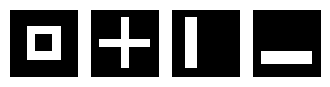

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. Configuration
# ==========================================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 16
Z_DIM = 2
BATCH_SIZE = 128
EPOCHS = 1000

# Hyperparameters
G_HIDDEN_DIM = 256
G_MID_DIM = 128
D_FIRST_DIM = 128
D_SECOND_DIM = 256
LR_G = 0.0002
LR_D = 0.0002

# ==========================================
# 2. Create "Toy" Dataset (4 Distinct Shapes)
# ==========================================
# We create 4 patterns: Square, Cross, Vertical Bar, Horizontal Bar
# Values are -1 to 1 (matching Tanh output)
def create_toy_data(n_samples=1000):
    data = torch.zeros(n_samples, 1, IMG_SIZE, IMG_SIZE) - 1.0 # Background = -1
    for i in range(n_samples):
        mode = i % 4
        if mode == 0: # Square
            data[i, 0, 4:12, 4:12] = 1.0
            data[i, 0, 6:10, 6:10] = -1.0
        elif mode == 1: # Cross
            data[i, 0, 2:14, 7:9] = 1.0
            data[i, 0, 7:9, 2:14] = 1.0
        elif mode == 2: # Vertical Bar
            data[i, 0, 2:14, 3:6] = 1.0
        elif mode == 3: # Horizontal Bar
            data[i, 0, 10:13, 2:14] = 1.0
    return data

# Prepare Data
real_data = create_toy_data(1024)
dataset = TensorDataset(real_data)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# Visualize Target Patterns
print("Target Patterns (Real Data):")
plt.figure(figsize=(4, 1))
patterns = real_data[:4]
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(patterns[i].squeeze(), cmap='gray', vmin=-1, vmax=1)
    plt.axis('off')
plt.show()

In [ ]:
# ==========================================
# 3. Micro-DCGAN Architecture
# ==========================================

class MicroGenerator(nn.Module):
    def __init__(self, hidden_dim=64, mid_dim=32):
        super(MicroGenerator, self).__init__()
        # Input: Z_DIM
        # Project to 4x4 feature map
        self.fc = nn.Sequential(
            nn.Linear(Z_DIM, hidden_dim * 4 * 4),
            nn.BatchNorm1d(hidden_dim * 4 * 4),
            nn.ReLU(True)
        )

        # Upsample: 4x4 -> 8x8 -> 16x16
        self.conv = nn.Sequential(
            # 4x4 -> 8x8
            nn.ConvTranspose2d(hidden_dim, mid_dim, 4, 2, 1),
            nn.BatchNorm2d(mid_dim),
            nn.ReLU(True),

            # 8x8 -> 16x16
            nn.ConvTranspose2d(mid_dim, 1, 4, 2, 1),
            nn.Tanh() # Output -1 to 1
        )

        self.hidden_dim = hidden_dim

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, self.hidden_dim, 4, 4)
        return self.conv(x)

class MicroDiscriminator(nn.Module):
    def __init__(self, first_dim=16, second_dim=32):
        super(MicroDiscriminator, self).__init__()
        # WEAK DISCRIMINATOR: Few filters (16) to prevent overpowering G
        self.net = nn.Sequential(
            # 16x16 -> 8x8
            nn.Conv2d(1, first_dim, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            # 8x8 -> 4x4
            nn.Conv2d(first_dim, second_dim, 4, 2, 1),
            nn.BatchNorm2d(second_dim),
            nn.LeakyReLU(0.2, inplace=True),

            # Flatten & Output
            nn.Flatten(),
            nn.Linear(second_dim * 4 * 4, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Initialize
G = MicroGenerator(hidden_dim=G_HIDDEN_DIM, mid_dim=G_MID_DIM).to(DEVICE)
D = MicroDiscriminator(first_dim=D_FIRST_DIM, second_dim=D_SECOND_DIM).to(DEVICE)

optimizerG = optim.Adam(G.parameters(), lr=LR_G, betas=(0.5, 0.999))
optimizerD = optim.Adam(D.parameters(), lr=LR_D, betas=(0.5, 0.999))
criterion = nn.BCELoss()

In [ ]:
# ==========================================
# 4. Training Loop
# ==========================================
print("Starting training...")
G_losses = []
D_losses = []

for epoch in range(EPOCHS):
    for i, (real_imgs,) in enumerate(dataloader):
        real_imgs = real_imgs.to(DEVICE)
        b_size = real_imgs.size(0)

        # ============================================
        #  TODO 1: Train Discriminator
        # ============================================
        # Goal: Maximize log(D(x)) + log(1 - D(G(z)))
        # 1. Zero out gradients for D
        # 2. Train with Real Data:
        #    - Create labels for real data (ones)
        #    - Forward pass real images through D
        #    - Calculate loss
        # 3. Train with Fake Data:
        #    - Generate noise z
        #    - Generate fake images with G
        #    - Create labels for fake data (zeros)
        #    - Forward pass fake images through D (Tip: use .detach() on images)
        #    - Calculate loss
        # 4. Update D weights
        D.requires_grad_(True)
        optimizerD.zero_grad()
        real_labels = torch.ones((b_size, 1), device="cuda")
        real_logits = D(real_imgs)
        d_real_loss = criterion(real_logits, real_labels)

        z = torch.randn((b_size, Z_DIM), device="cuda")
        fake_imgs = G(z)
        fake_labels = torch.zeros((b_size, 1), device="cuda")
        fake_logits = D(fake_imgs.detach())
        d_fake_loss = criterion(fake_logits, fake_labels)

        # ... Your code here ...
        loss_D = 0.5 * (d_real_loss + d_fake_loss) # Placeholder, replace with actual loss calculation
        loss_D.backward()
        optimizerD.step()

        # ============================================
        #  TODO 2: Train Generator
        # ============================================
        # Goal: Maximize log(D(G(z)))
        # 1. Zero out gradients for G
        # 2. Generate fake images (if not reused from above)
        # 3. Create labels for generator (ones) -> We want D to think they are real
        # 4. Forward pass fake images through D
        # 5. Calculate loss
        # 6. Update G weights
        D.requires_grad_(False)
        optimizerG.zero_grad()

        gen_logits = D(fake_imgs)
        # ... Your code here ...
        loss_G = criterion(gen_logits, real_labels) # Placeholder, replace with actual loss calculation

        loss_G.backward()
        optimizerG.step()

    # Logging
    G_losses.append(loss_G.item())
    D_losses.append(loss_D.item())

    if (epoch+1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] Loss D: {loss_D.item():.4f}, Loss G: {loss_G.item():.4f}")


Starting training...
Epoch [50/1000] Loss D: 0.5127, Loss G: 1.3244
Epoch [100/1000] Loss D: 0.3449, Loss G: 1.3038
Epoch [150/1000] Loss D: 0.3692, Loss G: 1.1200
Epoch [200/1000] Loss D: 0.7223, Loss G: 1.2630
Epoch [250/1000] Loss D: 0.2668, Loss G: 1.4442
Epoch [300/1000] Loss D: 0.3972, Loss G: 1.5600
Epoch [350/1000] Loss D: 0.2492, Loss G: 1.8414
Epoch [400/1000] Loss D: 0.4844, Loss G: 1.6047
Epoch [450/1000] Loss D: 0.6576, Loss G: 0.7470
Epoch [500/1000] Loss D: 0.1769, Loss G: 2.0570
Epoch [550/1000] Loss D: 0.6461, Loss G: 1.5832
Epoch [600/1000] Loss D: 0.0032, Loss G: 6.6401
Epoch [650/1000] Loss D: 0.5706, Loss G: 1.1103
Epoch [700/1000] Loss D: 0.4485, Loss G: 1.9912
Epoch [750/1000] Loss D: 0.1662, Loss G: 1.6081
Epoch [800/1000] Loss D: 0.0617, Loss G: 3.8072
Epoch [850/1000] Loss D: 0.2110, Loss G: 1.9357
Epoch [900/1000] Loss D: 0.0211, Loss G: 6.1992
Epoch [950/1000] Loss D: 0.4600, Loss G: 0.9950
Epoch [1000/1000] Loss D: 0.0620, Loss G: 3.1460


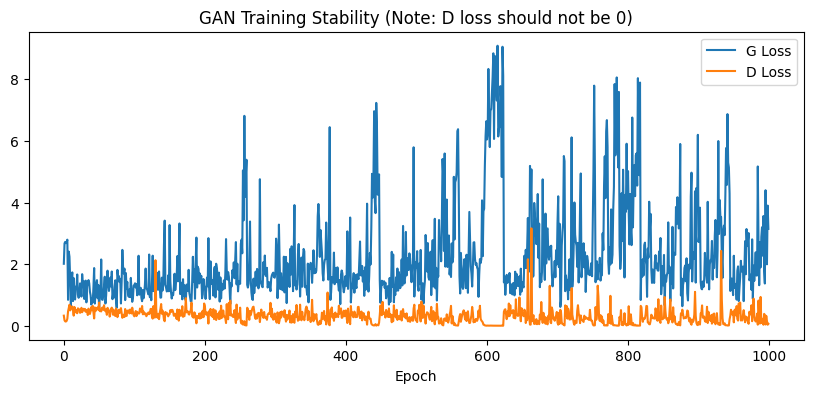

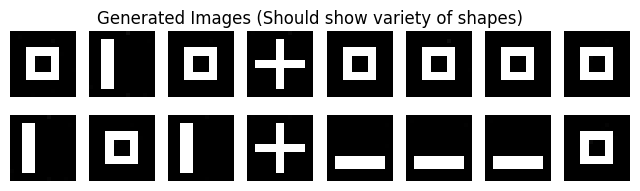

Models saved.


In [ ]:
# ==========================================
# 5. Visualization & Saving
# ==========================================

# A. Loss Curve
plt.figure(figsize=(10, 4))
plt.plot(G_losses, label="G Loss")
plt.plot(D_losses, label="D Loss")
plt.title("GAN Training Stability (Note: D loss should not be 0)")
plt.xlabel("Epoch")
plt.legend()
plt.show()

# B. Generated Samples (Check for Mode Collapse)
G.eval()
with torch.no_grad():
    # Generate enough samples to hopefully see all 4 modes
    z_vis = torch.randn(16, Z_DIM).to(DEVICE)
    gen_imgs = G(z_vis).cpu()

plt.figure(figsize=(8, 2))
plt.suptitle("Generated Images (Should show variety of shapes)")
for i in range(16):
    plt.subplot(2, 8, i+1)
    plt.imshow(gen_imgs[i].squeeze(), cmap='gray', vmin=-1, vmax=1)
    plt.axis('off')
plt.show()

# C. Save Models
torch.save(G.state_dict(), "micro_gan_generator.pth")
torch.save(D.state_dict(), "micro_gan_discriminator.pth")
print("Models saved.")